In [1]:
import requests
import pandas as pd
from bs4 import BeautifulSoup
from pathlib import Path
import re
import xml.etree.ElementTree as ET
from functools import reduce
import openpyxl
from scipy.optimize import minimize_scalar
import numpy as np
import glob
import datetime as dt
from semopy import Model
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf, ccf, grangercausalitytests, zivot_andrews
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch, breaks_cusumolsresid
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.api import VAR
from statsmodels.tools.tools import add_constant
from statsmodels.formula.api import ols
from statsmodels.tsa.stattools import coint
from scipy.stats import shapiro

from semopy import Model
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from arch.unitroot import PhillipsPerron
from pmdarima.arima.utils import nsdiffs

pd.set_option('display.max_columns', None)

pd.set_option('display.max_columns', None)

In [2]:
GDP_URL = "https://stat.gov.ua/sdmx/workspaces/default:integration/registry/sdmx/3.0/data/dataflow/SSSU/DF_QUARTERLY_NATIONAL_ACCOUNTS/~/GROSS_DOM_PRODUCT.UA00000000000000000.CURR_PRICES._T.Q?c[TIME_PERIOD]=ge:2010-Q1+le:2025-Q4"

def fetch_sdmx_series1525(url: str) -> pd.DataFrame:
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/122.0.0.0 Safari/537.36"
        ),
        "Accept": "application/xml, text/xml, */*",
        "Referer": "https://stat.gov.ua/uk/development-api/sdmx-api-v3",
    }

    response = requests.get(url, headers=headers, timeout=60)
    response.raise_for_status()

    root = ET.fromstring(response.content)

    series = root.find(".//Series")
    if series is None:
        raise ValueError("No <Series> found in response")

    scale = pd.to_numeric(series.attrib.get("SCALE"), errors="coerce")

    rows = []
    for obs in series.findall("./Obs"):
        rows.append({
            "year_quarter": obs.attrib.get("TIME_PERIOD"),
            "value": pd.to_numeric(obs.attrib.get("OBS_VALUE"), errors="coerce"),
            "scale": scale
        })

    df = pd.DataFrame(rows)

    if df.empty:
        raise ValueError("Series found, but no observations were extracted")
    
    df['year_quarter'] = df['year_quarter'].str.replace('-', '')

    df = df[df['year_quarter'] < '2025Q1'].reset_index(drop=True)
    df['value'] = df['value'] * (10 ** df['scale'])


    return df[["year_quarter", "value"]].rename(columns={"value": "nominal_gdp"})

In [3]:
gdp_1525 = fetch_sdmx_series1525(GDP_URL)
gdp_1525

,year_quarter,nominal_gdp
0,2015Q1,375991000000
1,2015Q2,456715000000
2,2015Q3,566997000000
3,2015Q4,588841000000
4,2016Q1,455298000000
5,2016Q2,535701000000
6,2016Q3,671456000000
7,2016Q4,722912000000
8,2017Q1,591765000000
9,2017Q2,664307000000


In [ ]:
GDP_FILE = "raw_csvs/vvp_rik90-22_2021_100 (1).xlsx"
IPI_FILE = "raw_csvs/505.xlsx"


def parse_annual_gdp(file_path: str) -> pd.DataFrame:
    wb = openpyxl.load_workbook(file_path, data_only=True)
    ws = wb["Лист1"]

    rows = []
    for r in range(37, 42):
        year = ws[f"A{r}"].value
        gdp_current = ws[f"B{r}"].value
        gdp_prev_year_prices = ws[f"D{r}"].value

        rows.append({
            "year": int(year),
            "annual_nominal_gdp": float(gdp_current),
            "annual_gdp_prev_year_prices": float(gdp_prev_year_prices),
        })

    df = pd.DataFrame(rows)
    df["annual_gdp_deflator"] = (
        df["annual_nominal_gdp"] / df["annual_gdp_prev_year_prices"] * 100
    )
    return df


def parse_quarterly_ipi(file_path: str) -> pd.DataFrame:
    wb = openpyxl.load_workbook(file_path, data_only=True)
    ws = wb["ІПП_ua"]

    data = list(ws.values)
    df = pd.DataFrame(data[2:], columns=["code", "attributes", "period", "data"])
    df = df.dropna(subset=["code", "period", "data"]).copy()

    df = df[df["code"].astype(str).str.strip() == "02"].copy()

    df["period"] = pd.to_datetime(
        df["period"].astype(str).str.replace(" ", "-", regex=False) + "-01"
    )
    df["ipi"] = pd.to_numeric(df["data"], errors="coerce")

    df["year"] = df["period"].dt.year
    df["quarter"] = df["period"].dt.quarter

    q = (
        df.groupby(["year", "quarter"], as_index=False)["ipi"]
        .mean()
        .sort_values(["year", "quarter"])
        .reset_index(drop=True)
    )

    q["year_quarter"] = q["year"].astype(str) + "-Q" + q["quarter"].astype(str)
    return q[["year", "quarter", "year_quarter", "ipi"]]


def build_conversion_matrix(n_years: int, s: int = 4, agg: str = "sum") -> np.ndarray:
    C = np.zeros((n_years, n_years * s))

    for i in range(n_years):
        if agg == "sum":
            C[i, i * s:(i + 1) * s] = 1.0
        elif agg == "average":
            C[i, i * s:(i + 1) * s] = 1.0 / s
        else:
            raise ValueError("agg must be 'sum' or 'average'")

    return C


def ar1_covariance(T: int, rho: float) -> np.ndarray:
    idx = np.arange(T)
    return rho ** np.abs(np.subtract.outer(idx, idx))


def chow_lin_disaggregate(
    y_low: np.ndarray,
    x_high: np.ndarray,
    s: int = 4,
    agg: str = "sum",
    include_const: bool = True,
):
    y_low = np.asarray(y_low, dtype=float).reshape(-1, 1)
    x_high = np.asarray(x_high, dtype=float).reshape(-1, 1)

    n_years = len(y_low)
    n_quarters = len(x_high)

    if n_quarters != n_years * s:
        raise ValueError("Length of high-frequency indicator must equal n_years * s")

    X_high = x_high
    if include_const:
        X_high = np.column_stack([np.ones(n_quarters), x_high[:, 0]])

    C = build_conversion_matrix(n_years=n_years, s=s, agg=agg)
    X_low = C @ X_high

    def objective(rho):
        Sigma = ar1_covariance(n_quarters, rho)
        V = C @ Sigma @ C.T

        try:
            V_inv = np.linalg.inv(V)
            beta = np.linalg.solve(X_low.T @ V_inv @ X_low, X_low.T @ V_inv @ y_low)
            resid = y_low - X_low @ beta
            sign, logdet = np.linalg.slogdet(V)

            if sign <= 0:
                return 1e12

            return float(logdet + (resid.T @ V_inv @ resid).item())
        except np.linalg.LinAlgError:
            return 1e12

    opt = minimize_scalar(objective, bounds=(-0.99, 0.99), method="bounded")
    rho_hat = opt.x

    Sigma = ar1_covariance(n_quarters, rho_hat)
    V = C @ Sigma @ C.T
    V_inv = np.linalg.inv(V)

    beta_hat = np.linalg.solve(X_low.T @ V_inv @ X_low, X_low.T @ V_inv @ y_low)

    y_high_hat = (
        X_high @ beta_hat
        + Sigma @ C.T @ V_inv @ (y_low - C @ (X_high @ beta_hat))
    )

    return y_high_hat.ravel(), rho_hat


annual_df = parse_annual_gdp(GDP_FILE)
ipi_q_df = parse_quarterly_ipi(IPI_FILE)

ipi_2010_2014 = ipi_q_df[(ipi_q_df["year"] >= 2010) & (ipi_q_df["year"] <= 2014)].copy()

quarterly_gdp, rho_gdp = chow_lin_disaggregate(
    y_low=annual_df["annual_nominal_gdp"].to_numpy(),
    x_high=ipi_2010_2014["ipi"].to_numpy(),
    s=4,
    agg="sum",
    include_const=True,
)

quarterly_deflator, rho_deflator = chow_lin_disaggregate(
    y_low=annual_df["annual_gdp_deflator"].to_numpy(),
    x_high=ipi_2010_2014["ipi"].to_numpy(),
    s=4,
    agg="average",
    include_const=True,
)

gdp_def_1014 = ipi_2010_2014[["year_quarter", "ipi"]].copy()
gdp_def_1014["quarterly_nominal_gdp"] = quarterly_gdp
gdp_def_1014["same_period_prev_year_2021_prices"] = quarterly_deflator

gdp_def_1014["quarterly_nominal_gdp"] = gdp_def_1014["quarterly_nominal_gdp"].round(2)
gdp_def_1014["same_period_prev_year_2021_prices"] = gdp_def_1014["same_period_prev_year_2021_prices"].round(2)
gdp_def_1014["scale"] = 6.0

gdp_def_1014 = gdp_def_1014[["year_quarter", "quarterly_nominal_gdp", "same_period_prev_year_2021_prices", "scale"]].copy()

In [8]:
gdp_def_1014['year_quarter'] = gdp_def_1014['year_quarter'].str.replace('-', '')
gdp_def_1014['quarterly_nominal_gdp'] = gdp_def_1014['quarterly_nominal_gdp'] * (10 ** gdp_def_1014['scale'])
gdp_def_1014 = gdp_def_1014[["year_quarter", "quarterly_nominal_gdp"]].rename(columns={"quarterly_nominal_gdp": "nominal_gdp"})
gdp_def_1014

,year_quarter,nominal_gdp
16,2010Q1,2.708323e+11
17,2010Q2,2.626266e+11
18,2010Q3,2.668010e+11
19,2010Q4,2.790862e+11
20,2011Q1,3.034000e+11
21,2011Q2,3.219657e+11
22,2011Q3,3.325906e+11
23,2011Q4,3.420346e+11
24,2012Q1,3.488093e+11
25,2012Q2,3.477758e+11


# Seasonally adjusted

<Axes: xlabel='year_quarter'>

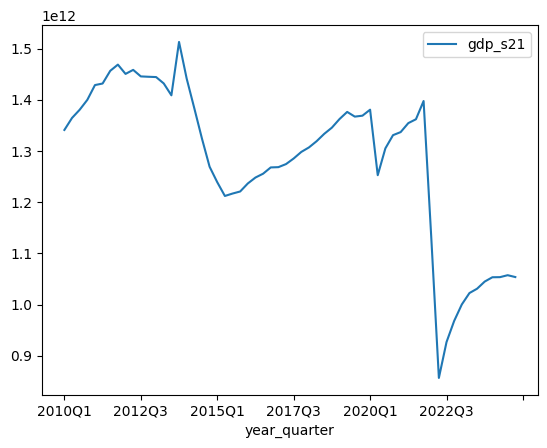

In [10]:
s_gdp = pd.read_excel('raw_csvs/vvp_kv_sez.xlsx',
    sheet_name=0,
    header=None,
    usecols="B:BI"
)

s_gdp = pd.DataFrame({
    "year_quarter": s_gdp.iloc[3].values,
    "gdp_s21": s_gdp.iloc[7] * 1e6
})

s_gdp.plot(x="year_quarter", y="gdp_s21", kind="line")

In [11]:
data10_21 = pd.read_excel("raw_csvs/vvp_kv_din_ue.xlsx", sheet_name=1, header=3)
data10_21 = data10_21.dropna()
data10_21 = data10_21[["Periods", "Gross domestic product"]]

In [ ]:
def read_data(year: int) -> pd.DataFrame:
    data = pd.read_excel(f"raw_csvs/vvpf_{year % 1000}_ue.xlsx", sheet_name="Лист1", skiprows=3, nrows=2, header=None)
    data = data.drop(columns=[0, 6])

    periods = [str(year), "I", "II", "III", "IV"]
    values = data.iloc[1, 0:-1].tolist()

    result = pd.DataFrame({
        "Periods": periods,
        "Gross domestic product": pd.Series([data.iloc[1,-1]] + values, dtype="float64")
    })

    return result

datas22_24 = [read_data(year) for year in [2022, 2023, 2024]]
data = pd.concat([data10_21]+datas22_24, ignore_index=True)

data = data.copy()

data["year"] = pd.to_numeric(data["Periods"], errors="coerce")

data["year"] = data["year"].ffill().astype(int)
data['Periods'] = data['Periods'].astype(str).str.strip()

q_map = {
    "I": "Q1",
    "II": "Q2",
    "III": "Q3",
    "IV": "Q4"
}

data = data[data["Periods"].isin(q_map.keys())].copy()

data["year_quarter"] = data["year"].astype(str) + data["Periods"].map(q_map)
data["gdp_2"] = pd.to_numeric(data["Gross domestic product"], errors="coerce") * 1e6

data = data[["year_quarter", "gdp_2"]].reset_index(drop=True)

data.head()

,year_quarter,gdp_2
0,2010Q1,2.170740e+11
1,2010Q2,2.555450e+11
2,2010Q3,3.004460e+11
3,2010Q4,3.062810e+11
4,2011Q1,2.585910e+11


# Final

In [13]:
final = pd.concat([gdp_def_1014, gdp_1525], ignore_index=True)\
    .merge(s_gdp, on="year_quarter")\
    .merge(data, on="year_quarter", how="left")\
    .sort_values("year_quarter").reset_index(drop=True)
final.to_csv("data/quarterly_nominal_gdp.csv", index=False)
final

,year_quarter,nominal_gdp,gdp_s21,gdp_2
0,2010Q1,2.708323e+11,1341048000000.0,2.170740e+11
1,2010Q2,2.626266e+11,1364544000000.0,2.555450e+11
2,2010Q3,2.668010e+11,1380542000000.0,3.004460e+11
3,2010Q4,2.790862e+11,1399885000000.0,3.062810e+11
4,2011Q1,3.034000e+11,1428757000000.0,2.585910e+11
5,2011Q2,3.219657e+11,1431777000000.0,3.102770e+11
6,2011Q3,3.325906e+11,1456604000000.0,3.684880e+11
7,2011Q4,3.420346e+11,1468721000000.0,3.626350e+11
8,2012Q1,3.488093e+11,1450569000000.0,2.923240e+11
9,2012Q2,3.477758e+11,1458445000000.0,3.460050e+11


<Axes: xlabel='year_quarter'>

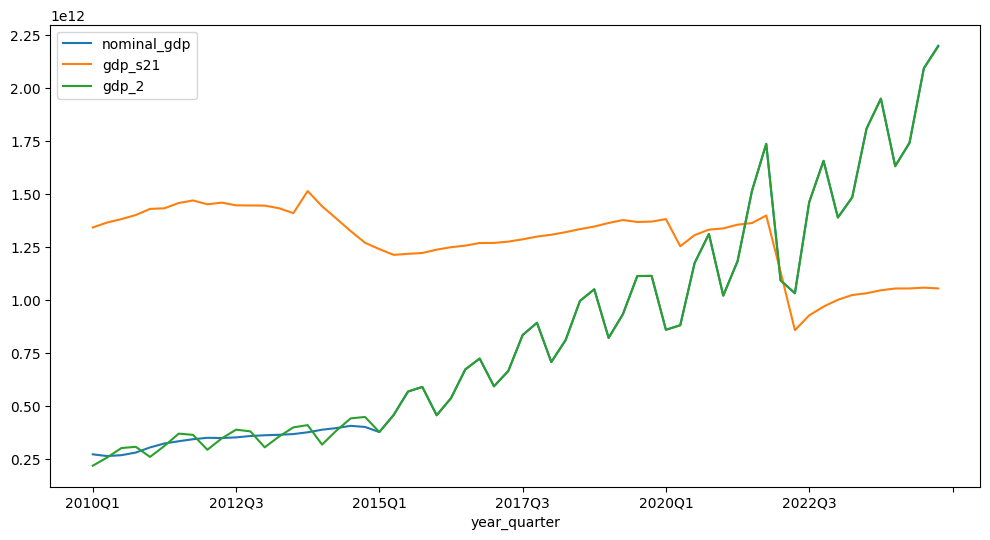

In [14]:
final.plot(x="year_quarter", y=["nominal_gdp", "gdp_s21", "gdp_2"], kind="line", figsize=(12, 6))

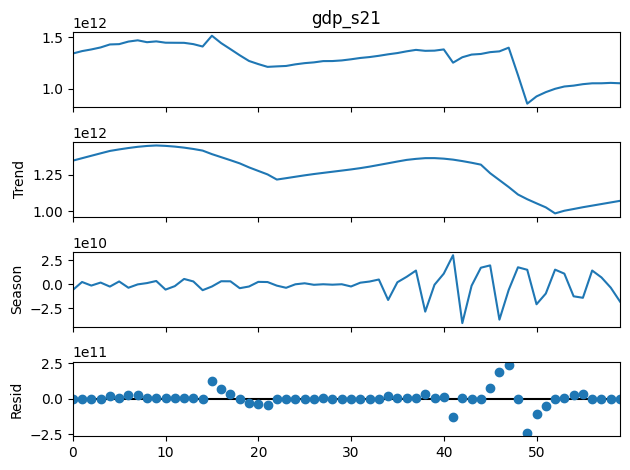

,variable,seasonal_strength
0,gdp_s21,0


In [15]:
from matplotlib import pyplot as plt
from statsmodels.tsa.seasonal import STL
cols = ['nominal_gdp', 'gdp_s21']

seasonality_results = []

s = final[cols[1]].dropna()

stl = STL(s, period=4, robust=True)
res = stl.fit()
fig = res.plot()
plt.show()

stl = STL(s, period=4, robust=True).fit()
seasonal = stl.seasonal
resid = stl.resid

strength = max(0, 1 - np.var(resid) / np.var(seasonal + resid))
seasonality_results.append({
    "variable": cols[1],
    "seasonal_strength": strength
})

seasonality_df = pd.DataFrame(seasonality_results)
seasonality_df

In [16]:
## suggested number of seasonal differences

ocsb_results = []

for col in cols:
    s = final[col].dropna()

    if len(s) < 12:
        continue

    try:
        D = nsdiffs(s, m=4, test="ocsb")
        ocsb_results.append({
            "variable": col,
            "suggested_seasonal_diffs": D
        })
    except:
        pass

ocsb_df = pd.DataFrame(ocsb_results)
ocsb_df

,variable,suggested_seasonal_diffs
0,nominal_gdp,1
1,gdp_s21,0


In [17]:
results_stationarity = []

for col in cols:
    s = pd.to_numeric(final[col], errors="coerce").dropna()
    s = s.astype(float)

    if len(s) < 10:
        continue

    try:
        adf_stat, adf_p, _, _, _, _ = adfuller(s, autolag="AIC")
    except Exception as e:
        adf_p = np.nan
        print(f"ADF failed for {col}: {e}")

    try:
        kpss_stat, kpss_p, _, _ = kpss(s, regression="c", nlags="auto")
    except Exception as e:
        kpss_p = np.nan
        print(f"KPSS failed for {col}: {e}")

    try:
        pp = PhillipsPerron(s)
        pp_p = pp.pvalue
    except Exception as e:
        pp_p = np.nan
        print(f"PP failed for {col}: {e}")

    results_stationarity.append({
        "variable": col,
        "adf_p": adf_p,
        "pp_p": pp_p,
        "kpss_p": kpss_p
    })

stationarity_df = pd.DataFrame(results_stationarity)
stationarity_df

,variable,adf_p,pp_p,kpss_p
0,nominal_gdp,1.000000,0.997194,0.01
1,gdp_s21,0.439866,0.668738,0.01
